# Análisis de reseñas de `fixauto.com`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias


In [1]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.feature_extraction import text
from transformers import pipeline
import nltk
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = 5000  # Ejemplo: 5000 para pruebas rapidas
TARGET = "fixauto.com"
CAT = "Vehicles & Transportation"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

### trustpilot-reviews-123k

In [3]:
df = pd.read_csv("data/trustpilot-reviews-123k.csv")
df.sample(10)

,category,company,description,title,review,stars
97135,Education & Training,www.thepasspeople.co.uk,The Pass People offer intensive driving course...,Great Service,Very friendly service and very quick too. Woul...,4
15930,Hobbies & Crafts,ejaydesign.com,Bespoke watercolour maps with hand-painted gol...,Fabulous design.,Fabulous design.Delivery better than I needed....,5
99098,Legal Services & Government,www.zenco.com,Zenco Legal\nWe focus on you to bring legal se...,Over two weeks we placed order,"Over two weeks we placed order, still no paper...",1
98954,Legal Services & Government,www.dclaw.co.uk,"For two decades, DC Law has been providing a c...",Overall,"Overall, we were satisfied with the service, w...",3
119831,Utilities,aidfuels.co.uk,"\nSIMPLE, QUICK & EFFICIENT FUEL OIL ORDERING\...",The Company is entirely trusted.,The Company is entirely trusted in the role th...,5
73514,Utilities,castlewater.co.uk,"Unlike many water retailers, Castle Water is n...",Getting in touch was very trying,Getting in touch was very trying. I gave up wi...,3
60279,Travel & Vacation,kenwoodtravel.co.uk,Kenwood Travel has over 45 years' experience i...,Our go to company,"Great company to deal with, competitive pricin...",5
19903,Animals & Pets,funnyfuzzy.co.uk,"HI, WE'RE FUNNYFUZZY.\nWe believe having them ...","Great product, just be aware of delivery times.",Ordered two covers for Christmas to give the s...,4
90256,Public & Local Services,www.purecremation.co.uk,About Pure Cremation \n Pure Cremation provide...,I thought cold calling was illegal.,I thought cold calling in this country was ill...,1
91148,Public & Local Services,relativeconnections.co.uk,Relative Connections is the UK’s leading Traci...,I’m not sure this company does what it…,I’m not sure this company does what it says. T...,1


Viendo si hay valores nulos

In [4]:
df.isnull().sum()

category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

### emp_100_reviews.xlsx - Sheet1

In [5]:
summary = pd.read_csv("data/emp_100_reviews.xlsx - Sheet1.csv")
summary.sample(10)  

,category,company,n_reviews,median_stars,media_stars,std_stars
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338
300,Education & Training,thettcgroup.com,100,3,3,1.421338
275,Travel & Vacation,www.barrheadtravel.co.uk,100,3,3,1.421338
175,Utilities,pozitive.energy,100,3,3,1.421338
258,Utilities,eonnext.com,100,3,3,1.421338
399,Construction & Manufacturing,www.cromwell.co.uk,100,3,3,1.421338
19,Restaurants & Bars,berwickshellfish.com,100,3,3,1.421338
157,Utilities,www.scottishpower.co.uk,100,3,3,1.421338
26,Public & Local Services,www.ancestry.co.uk,100,3,3,1.421338
277,Travel & Vacation,trip.com,100,3,3,1.421338


Viendo si hay valores nulos

In [6]:
summary.isnull().sum()

category        0
company         0
n_reviews       0
median_stars    0
media_stars     0
std_stars       0
dtype: int64

Viendo si hay duplicados en la tabla resumen

In [7]:

summary.duplicated().any()

False

In [8]:
competencia = summary.query("category == @CAT & n_reviews <= 100 & company != @TARGET").company
competencia.unique()

<StringArray>
[              'brompton.com',            '1stchoice.co.uk',
               'etyres.co.uk',              'revive-uk.com',
         'farmerautocare.com',              'flixbus.co.uk',
                 'haynes.com',               'justpark.com',
          'paulscycles.co.uk',              'pod-point.com',
            'sigmasports.com',          'www.poferries.com',
         'www.national.co.uk',    'www.nationalexpress.com',
            'www.ohme-ev.com',      'www.paddockspares.com',
          'www.planetx.co.uk',      'www.plates4less.co.uk',
          'www.protyre.co.uk',   'taxis.gatwickairport.com',
     'www.regtransfers.co.uk',    'www.sportandleisure.com',
       'www.thetrainline.com',            'www.tredz.co.uk',
        'www.webuyanycar.com', 'www.winstanleysbikes.co.uk',
       'www.merlincycles.com',  'www.leisurelakesbikes.com',
           'www.kwik-fit.com',     'www.huntbikewheels.com',
           'www.halfords.com',      'www.ferryonline.co.uk',
    'www.f

## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [9]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

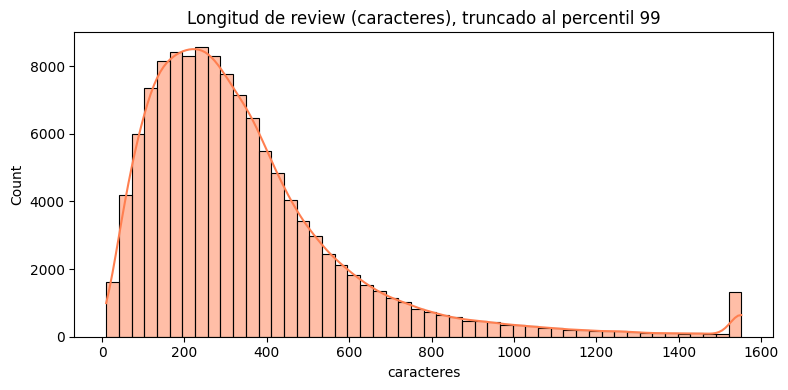

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [11]:
import re

def limpieza(texto: str) -> str:
    texto = texto.replace("\n", " ")        # elimina saltos de línea
    texto = texto.lower()                   # a minúsculas
    texto = re.sub(r"[^\w ]+", "", texto)   # elimina caracteres especiales
    return texto

df = df.assign(
    title       = df.title.apply(limpieza),
    review      = df.review.apply(limpieza),
    description = df.description.apply(limpieza)
)

Viendo si hay duplicados

In [12]:
df.duplicated().any()

False

## 6) Filtrado del sector de la compañía objetivo

In [13]:
#Datos de la competencia
df_competencia=df[df.company.isin(competencia)]
#Datos de la empresa
df_empresa=df[df.company==TARGET]

In [14]:
df_competencia.sample(10)

,category,company,description,title,review,stars,review_len
79645,Vehicles & Transportation,www.huntbikewheels.com,hunt bike wheels exists because the wheels we ...,customer service has now become,customer service has now become rubbish befou...,1,341
77254,Vehicles & Transportation,www.kwik-fit.com,kwik fit are the leading fast fit and automoti...,absolutely useless place to get your,absolutely useless place to get your service d...,1,237
77216,Vehicles & Transportation,www.kwik-fit.com,kwik fit are the leading fast fit and automoti...,booked tyre replacement for the monday,booked tyre replacement for the monday and was...,3,69
76594,Vehicles & Transportation,www.planetx.co.uk,founded in sheffield england over a quarter of...,i paid extra for express delivery and,i paid extra for express delivery and the smal...,1,99
76073,Vehicles & Transportation,www.autowindscreens.co.uk,a leading automotive glass repair and replacem...,no glass in stock,no glass in stock had to drive 200miles with n...,2,217
78412,Vehicles & Transportation,www.sportandleisure.com,were dedicated to providing you with the very ...,very port delivery service,very port delivery service needed an item deli...,2,135
77511,Vehicles & Transportation,www.leisurelakesbikes.com,leisure lakes bikes are a family run business ...,wouldnt price match,wouldnt price match and a bit of an attitude w...,2,64
77247,Vehicles & Transportation,www.kwik-fit.com,kwik fit are the leading fast fit and automoti...,wrong tyres supplied twice,1st visit 3 weeks ago wrong tyre size supplied...,2,380
80604,Vehicles & Transportation,1stchoice.co.uk,find a part fast buy cut price car parts with ...,ordered sum parts bac breaks disc for,ordered sum parts bac breaks disc for toyota c...,2,378
80863,Vehicles & Transportation,www.f1autocentres.co.uk,formula one autocentres currently boasts over ...,battery replacement,popped into my local branch for a battery repl...,4,329


In [15]:
df_empresa.sample(10)

,category,company,description,title,review,stars,review_len
121975,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,excellent service,really friendly from the moment you enter the ...,5,126
121985,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,can i just say first that everyone was very he...,can i just say first that everyone was very he...,4,478
121961,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,efficient service regular contact with the cus...,vehicle off the road for a month which coincid...,5,354
122030,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,items money missing from car upon return,car came back repaired but unfortunately items...,2,248
122024,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,communication wasnt great,communication wasnt great had to keep calling ...,2,276
121972,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,impeccable service with high quality workmanship,i recently had the pleasure of using fix auto ...,5,936
122048,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,poor service,poor servicedont keep customer updatedreceptio...,1,177
121963,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,auto fix,auto fix from start to finish where so profess...,5,188
121965,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,great service and excellent paint job,long wait to get car into workshop but from th...,5,347
121982,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,the job was perfectly and swiftly,the job was perfectly and swiftly executed the...,4,88


Comparando las estrellas en promedio

In [16]:
stars_prom= pd.DataFrame({
    "Empresa": [ TARGET, "Competencia"],
    "Stars promedio": [df_empresa.stars.mean().round(2), df_competencia.stars.mean().round(2)]
})
display(stars_prom)

,Empresa,Stars promedio
0,fixauto.com,3.0
1,Competencia,3.0


## 7) Sentimiento
Aplicamos el análisis de sentimiento sobre `df_empresa` y `df_competencia` respecto a `review` usando un modelo de HuggingFace.

In [17]:
# Sentimiento con pipeline de HuggingFace (distilbert-sst2, rapido y ligero)
# Truncamos a 512 tokens que es el maximo del modelo
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    device=-1  # CPU; cambia a 0 si tienes GPU
)

def batch_sentiment(texts, batch_size=64):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size].tolist()
        out = sentiment_pipe(batch)
        results.extend(out)
    labels = [r["label"] for r in results]
    scores = [r["score"] for r in results]
    return labels, scores

# --- data_empresa ---
print("Analizando sentimiento de la empresa...")
labels_e, scores_e = batch_sentiment(df_empresa["review"])
data_empresa = df_empresa.copy()
data_empresa["sentiment"]       = labels_e
data_empresa["sentiment_score"] = scores_e

# --- data_competencia ---
print("Analizando sentimiento de la competencia...")
labels_c, scores_c = batch_sentiment(df_competencia["review"])
data_competencia = df_competencia.copy()
data_competencia["sentiment"]       = labels_c
data_competencia["sentiment_score"] = scores_c

print("Listo.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Analizando sentimiento de la empresa...
Analizando sentimiento de la competencia...
Listo.


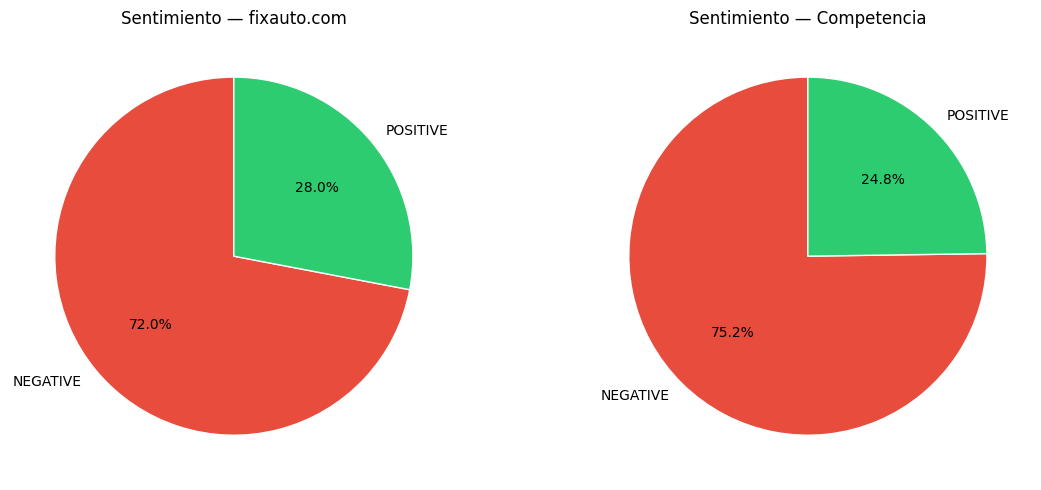

,empresa,competencia
sentiment,,
NEGATIVE,72,3310
POSITIVE,28,1090


In [18]:
# Resumen de sentimiento
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e74c3c", "#2ecc71"]

for ax, (df_plot, label) in zip(axes, [(data_empresa, TARGET), (data_competencia, "Competencia")]):
    counts = df_plot["sentiment"].value_counts()
    ax.pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )
    ax.set_title(f"Sentimiento — {label}")

plt.tight_layout()
plt.show()

# Tabla resumen
pd.DataFrame({
    "empresa": data_empresa["sentiment"].value_counts(),
    "competencia": data_competencia["sentiment"].value_counts()
})

## 8) Topics con BERTopic

In [19]:
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

_lemmatizer = WordNetLemmatizer()
_stop_words = set(CountVectorizer(stop_words="english").get_stop_words()) | {
    "wasnt", "wasnt", "didnt", "dont", "doesnt", "wouldnt", "couldnt",
    "shouldnt", "isnt", "arent", "werent", "havent", "hasnt", "hadnt",
    "wont", "cant", "ive", "im", "ive", "youre", "theyre", "weve",
    "theyve", "id", "wed", "theyd", "youll", "theyll", "thats", "whos"
}

def lemmatize_tokenizer(doc):
    import re
    # Solo tokens de 2+ letras puras (sin dígitos ni caracteres especiales)
    tokens = re.findall(r"\b[a-zA-Z]{2,}\b", doc)
    lemmas = []
    for t in tokens:
        t = t.lower()
        if t in _stop_words:
            continue
        lemma = _lemmatizer.lemmatize(t, pos="v")
        if lemma == t:
            lemma = _lemmatizer.lemmatize(t, pos="n")
        lemmas.append(lemma)
    return lemmas

def entrenar_bertopic(docs, n_topics=N_TOPICS):
    vectorizer = CountVectorizer(
        tokenizer=lemmatize_tokenizer,
        lowercase=False,
        min_df=1
    )
    model = BERTopic(
        vectorizer_model=vectorizer,
        nr_topics=n_topics,
        language="english",
        calculate_probabilities=False,
        verbose=True
    )
    topics, _ = model.fit_transform(docs)
    return model, topics

# --- data_empresa ---
print("=== BERTopic: data_empresa ===")
docs_empresa = data_empresa["review"].tolist()
model_empresa, topics_empresa = entrenar_bertopic(docs_empresa)
data_empresa["topic"] = topics_empresa

# --- data_competencia ---
print("\n=== BERTopic: data_competencia ===")
docs_competencia = data_competencia["review"].tolist()
model_compet, topics_competencia = entrenar_bertopic(docs_competencia)
data_competencia["topic"] = topics_competencia

print("\nListo.")

2026-06-20 16:45:11,020 - BERTopic - Embedding - Transforming documents to embeddings.


=== BERTopic: data_empresa ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026-06-20 16:45:15,839 - BERTopic - Embedding - Completed ✓
2026-06-20 16:45:15,840 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-20 16:45:26,608 - BERTopic - Dimensionality - Completed ✓
2026-06-20 16:45:26,608 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-20 16:45:26,617 - BERTopic - Cluster - Completed ✓
2026-06-20 16:45:26,618 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-20 16:45:29,398 - BERTopic - Representation - Completed ✓
2026-06-20 16:45:29,399 - BERTopic - Topic reduction - Reducing number of topics
2026-06-20 16:45:29,399 - BERTopic - Topic reduction - Number of topics (8) is equal or higher than the clustered topics(3).
2026-06-20 16:45:29,400 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-20 16:45:29,445 - BERTopic - Representation - Completed ✓
2026-06-20 16:45:29,487 - BERTopic - Embedding - Transforming documents to emb


=== BERTopic: data_competencia ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/138 [00:00<?, ?it/s]

2026-06-20 16:46:16,830 - BERTopic - Embedding - Completed ✓
2026-06-20 16:46:16,831 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-20 16:46:34,050 - BERTopic - Dimensionality - Completed ✓
2026-06-20 16:46:34,053 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-20 16:46:34,188 - BERTopic - Cluster - Completed ✓
2026-06-20 16:46:34,189 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-20 16:46:35,053 - BERTopic - Representation - Completed ✓
2026-06-20 16:46:35,055 - BERTopic - Topic reduction - Reducing number of topics
2026-06-20 16:46:35,082 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-20 16:46:35,932 - BERTopic - Representation - Completed ✓
2026-06-20 16:46:35,935 - BERTopic - Topic reduction - Reduced number of topics from 47 to 8



Listo.


In [20]:
# Topics de data_empresa
print("=== Topics — data_empresa ===")
info_empresa = model_empresa.get_topic_info()
display(info_empresa[info_empresa.Topic != -1][["Topic", "Count", "Name"]].head(N_TOPICS))

print("\n=== Topics — data_competencia ===")
info_compet = model_compet.get_topic_info()
display(info_compet[info_compet.Topic != -1][["Topic", "Count", "Name"]].head(N_TOPICS))

=== Topics — data_empresa ===


,Topic,Count,Name
1,0,13,0_service_car_repair_look
2,1,11,1_car_repair_good_get



=== Topics — data_competencia ===


,Topic,Count,Name
1,0,1877,0_tyre_bike_order_day
2,1,798,1_book_park_ferry_time
3,2,523,2_car_work_service_charger
4,3,87,3_mat_fit_quality_car
5,4,84,4_manual_haynes_information_online
6,5,75,5_size_glove_return_order
7,6,13,6_bulb_light_fit_holder


Visualizacion de topics — barchart de palabras clave por topic

In [21]:
for model, label in [(model_empresa, TARGET), (model_compet, "Competencia")]:
    n_real = len([t for t in model.get_topics() if t != -1])
    if n_real == 0:
        print(f"[{label}] No se encontraron topics significativos (todos son outliers).")
        continue
    top_n = min(n_real, N_TOPICS)
    fig = model.visualize_barchart(top_n_topics=top_n, n_words=TOP_WORDS, title=f"Topics — {label}")
    fig.show()

Sentimiento por topic

=== Sentimiento por topic — data_empresa ===


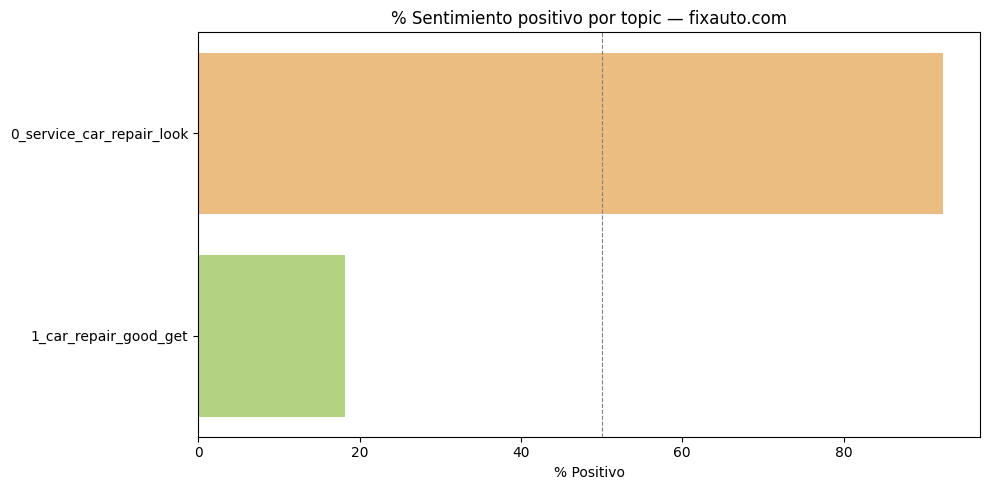

,topic_name,n_reviews,pct_positive
0,0_service_car_repair_look,13,92.3
1,1_car_repair_good_get,11,18.2



=== Sentimiento por topic — data_compet ===


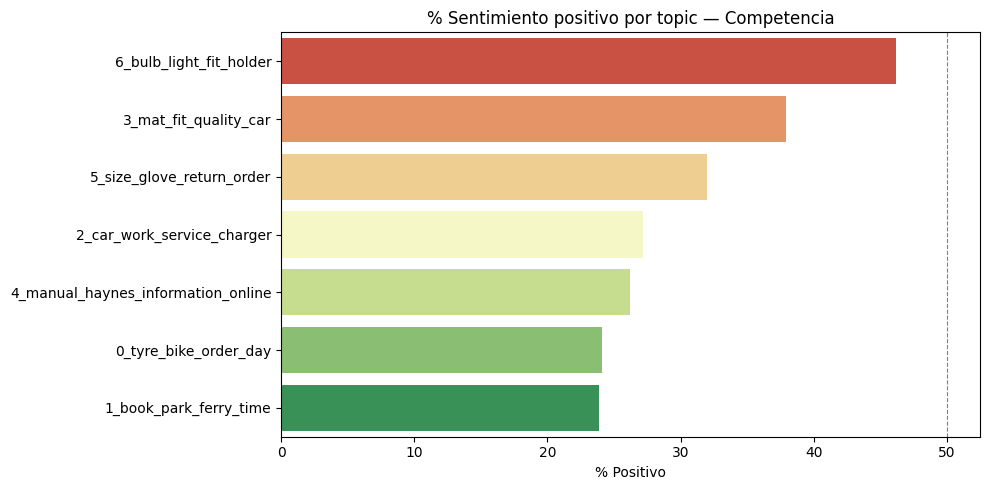

,topic_name,n_reviews,pct_positive
0,6_bulb_light_fit_holder,13,46.2
1,3_mat_fit_quality_car,87,37.9
2,5_size_glove_return_order,75,32.0
3,2_car_work_service_charger,523,27.2
4,4_manual_haynes_information_online,84,26.2
5,0_tyre_bike_order_day,1877,24.1
6,1_book_park_ferry_time,798,23.9


In [22]:
def sentiment_por_topic(df_in, model, label):
    topic_names = model.get_topic_info().set_index("Topic")["Name"].to_dict()
    df_tmp = df_in[df_in["topic"] != -1].copy()
    df_tmp["topic_name"] = df_tmp["topic"].map(topic_names)
    df_tmp["positive"] = (df_tmp["sentiment"] == "POSITIVE").astype(int)

    agg = (df_tmp.groupby("topic_name")
           .agg(n_reviews=("positive", "count"),
                pct_positive=("positive", "mean"))
           .sort_values("pct_positive", ascending=False)
           .reset_index())
    agg["pct_positive"] = (agg["pct_positive"] * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=agg, x="pct_positive", y="topic_name", palette="RdYlGn", ax=ax)
    ax.set_title(f"% Sentimiento positivo por topic — {label}")
    ax.set_xlabel("% Positivo")
    ax.set_ylabel("")
    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()
    return agg

print("=== Sentimiento por topic — data_empresa ===")
sent_empresa = sentiment_por_topic(data_empresa, model_empresa, TARGET)
display(sent_empresa)

print("\n=== Sentimiento por topic — data_compet ===")
sent_competencia = sentiment_por_topic(data_competencia, model_compet, "Competencia")
display(sent_competencia)

### Conclusiones
- Prevalece los comentarios negativos tanto en la empresa como en la competencia.
- En análisis de sentimientos por tópicos, aparecen más comentarios positivos en la empresa.